In [2]:
import pandas as pd 
import numpy as np 
import seaborn as sns
df = pd.DataFrame({
    'Order_ID':[101,102,103,104,105,106,107,108,109,110],
    'Customer':['A','B','C','A','D','B','E','A','C','D'],
    'Product':['Laptop','Mobile','Laptop','Headphones','Mobile',
               'Laptop','Tablet','Mobile','Tablet','Laptop'],
    'Category':['Electronics','Electronics','Electronics',
                'Accessories','Electronics','Electronics',
                'Electronics','Electronics','Electronics','Electronics'],
    'City':['Mumbai','Pune','Mumbai','Delhi','Pune',
            'Delhi','Mumbai','Pune','Delhi','Mumbai'],
    'Quantity':[1,2,1,3,1,2,1,1,2,1],
    'Price':[50000,20000,50000,2000,20000,
             50000,30000,20000,30000,50000],
    'Returned':[0,1,0,0,1,0,0,1,0,0]
})

df['Revenue'] = df['Quantity'] * df['Price']

df

,Order_ID,Customer,Product,Category,City,Quantity,Price,Returned,Revenue
0,101,A,Laptop,Electronics,Mumbai,1,50000,0,50000
1,102,B,Mobile,Electronics,Pune,2,20000,1,40000
2,103,C,Laptop,Electronics,Mumbai,1,50000,0,50000
3,104,A,Headphones,Accessories,Delhi,3,2000,0,6000
4,105,D,Mobile,Electronics,Pune,1,20000,1,20000
5,106,B,Laptop,Electronics,Delhi,2,50000,0,100000
6,107,E,Tablet,Electronics,Mumbai,1,30000,0,30000
7,108,A,Mobile,Electronics,Pune,1,20000,1,20000
8,109,C,Tablet,Electronics,Delhi,2,30000,0,60000
9,110,D,Laptop,Electronics,Mumbai,1,50000,0,50000


In [18]:
df.groupby("Category")["Price"].mean()

Category
Accessories     2000.000000
Electronics    35555.555556
Name: Price, dtype: float64

In [24]:
df.groupby("Product")["Price"].min()
# min,max,mean,median,count,var,std


Product
Headphones     2000
Laptop        50000
Mobile        20000
Tablet        30000
Name: Price, dtype: int64

In [25]:
df.groupby("Product")["Price"].sum().sort_values(ascending=True)
# it's give us smallest value.

Product
Headphones      2000
Mobile         60000
Tablet         60000
Laptop        200000
Name: Price, dtype: int64

In [26]:
df.groupby("Product")["Price"].sum().sort_values(ascending=False)
#it's give us largest value.

Product
Laptop        200000
Mobile         60000
Tablet         60000
Headphones      2000
Name: Price, dtype: int64

In [29]:
df.groupby("Revenue")["City"].sum().sort_values(ascending=False)
#it's give us largest value.

Revenue
20000               PunePune
40000                   Pune
50000     MumbaiMumbaiMumbai
30000                 Mumbai
6000                   Delhi
60000                  Delhi
100000                 Delhi
Name: City, dtype: object

In [30]:
df.groupby("City")["Revenue"].sum().sort_values(ascending=False)
# which city have largest revenue.

City
Mumbai    180000
Delhi     166000
Pune       80000
Name: Revenue, dtype: int64

In [ ]:
df.groupby("City")["Revenue"].max()

In [33]:
df.groupby("Customer")["Quantity"].sum().sort_values(ascending=False)
# which customer purches maximum quantity.

Customer
A    5
B    4
C    3
D    2
E    1
Name: Quantity, dtype: int64

# Filtering Questions

In [34]:
# customer with order_id greater then 105.(it's give us answer with true false)
df["Order_ID"] > 105

0    False
1    False
2    False
3    False
4    False
5     True
6     True
7     True
8     True
9     True
Name: Order_ID, dtype: bool

In [35]:
df[df["Order_ID"] > 105]

,Order_ID,Customer,Product,Category,City,Quantity,Price,Returned,Revenue
5,106,B,Laptop,Electronics,Delhi,2,50000,0,100000
6,107,E,Tablet,Electronics,Mumbai,1,30000,0,30000
7,108,A,Mobile,Electronics,Pune,1,20000,1,20000
8,109,C,Tablet,Electronics,Delhi,2,30000,0,60000
9,110,D,Laptop,Electronics,Mumbai,1,50000,0,50000


In [38]:
df[df["City"] == "Mumbai"]["Revenue"].sum()
# mumbai city revenue

np.int64(180000)

In [51]:
df[(df["Product"] == "Laptop") & (df["Quantity"] > 1) ]
# give us laptop having greater then 1 quantity.
#df.query("Product == 'Laptop' and Quantity > 1") #this line says solve using query.

,Order_ID,Customer,Product,Category,City,Quantity,Price,Returned,Revenue
5,106,B,Laptop,Electronics,Delhi,2,50000,0,100000


In [60]:
df.query("Customer == 'C' and Quantity >=0")

,Order_ID,Customer,Product,Category,City,Quantity,Price,Returned,Revenue
2,103,C,Laptop,Electronics,Mumbai,1,50000,0,50000
8,109,C,Tablet,Electronics,Delhi,2,30000,0,60000


In [62]:
df.query("not(Product == 'Laptop' and Quantity > 1)")

,Order_ID,Customer,Product,Category,City,Quantity,Price,Returned,Revenue
0,101,A,Laptop,Electronics,Mumbai,1,50000,0,50000
1,102,B,Mobile,Electronics,Pune,2,20000,1,40000
2,103,C,Laptop,Electronics,Mumbai,1,50000,0,50000
3,104,A,Headphones,Accessories,Delhi,3,2000,0,6000
4,105,D,Mobile,Electronics,Pune,1,20000,1,20000
6,107,E,Tablet,Electronics,Mumbai,1,30000,0,30000
7,108,A,Mobile,Electronics,Pune,1,20000,1,20000
8,109,C,Tablet,Electronics,Delhi,2,30000,0,60000
9,110,D,Laptop,Electronics,Mumbai,1,50000,0,50000


In [69]:
df["Category"].value_counts()

Category
Electronics    9
Accessories    1
Name: count, dtype: int64

In [73]:
df["Order_ID"].value_counts(bins=2)   

(100.99, 105.5]    5
(105.5, 110.0]     5
Name: count, dtype: int64

In [74]:
df["Product"].nunique()

4

In [75]:
df["Product"].unique()

array(['Laptop', 'Mobile', 'Headphones', 'Tablet'], dtype=object)

In [82]:
df[df["Product"].isin(["Mobile"])]

,Order_ID,Customer,Product,Category,City,Quantity,Price,Returned,Revenue
1,102,B,Mobile,Electronics,Pune,2,20000,1,40000
4,105,D,Mobile,Electronics,Pune,1,20000,1,20000
7,108,A,Mobile,Electronics,Pune,1,20000,1,20000


In [85]:
pd.crosstab(df["Product"], df["Order_ID"])

Order_ID,101,102,103,104,105,106,107,108,109,110
Product,,,,,,,,,,
Headphones,0,0,0,1,0,0,0,0,0,0
Laptop,1,0,1,0,0,1,0,0,0,1
Mobile,0,1,0,0,1,0,0,1,0,0
Tablet,0,0,0,0,0,0,1,0,1,0


In [86]:
import pandas as pd

data = {
    'Order_ID': [101,102,103,104,105,106,107,108,109,110],
    'Order_Date': [
        '2024-01-05',
        '2024-01-15',
        '2024-02-10',
        '2024-02-25',
        '2024-03-05',
        '2024-03-18',
        '2024-04-10',
        '2024-04-20',
        '2024-05-15',
        '2024-05-28'
    ],
    'Product': [
        'Laptop','Mobile','Laptop','Tablet','Mobile',
        'Laptop','Tablet','Mobile','Laptop','Tablet'
    ],
    'Sales': [
        50000,25000,55000,18000,30000,
        60000,22000,28000,65000,24000
    ]
}

df = pd.DataFrame(data)

df['Order_Date'] = pd.to_datetime(df['Order_Date'])

df

,Order_ID,Order_Date,Product,Sales
0,101,2024-01-05,Laptop,50000
1,102,2024-01-15,Mobile,25000
2,103,2024-02-10,Laptop,55000
3,104,2024-02-25,Tablet,18000
4,105,2024-03-05,Mobile,30000
5,106,2024-03-18,Laptop,60000
6,107,2024-04-10,Tablet,22000
7,108,2024-04-20,Mobile,28000
8,109,2024-05-15,Laptop,65000
9,110,2024-05-28,Tablet,24000


In [90]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

In [91]:
df["Month"] = df["Order_Date"].dt.month_name()

In [92]:
df

,Order_ID,Order_Date,Product,Sales,Month
0,101,2024-01-05,Laptop,50000,January
1,102,2024-01-15,Mobile,25000,January
2,103,2024-02-10,Laptop,55000,February
3,104,2024-02-25,Tablet,18000,February
4,105,2024-03-05,Mobile,30000,March
5,106,2024-03-18,Laptop,60000,March
6,107,2024-04-10,Tablet,22000,April
7,108,2024-04-20,Mobile,28000,April
8,109,2024-05-15,Laptop,65000,May
9,110,2024-05-28,Tablet,24000,May


In [95]:
# 1 montly sum sales
df.groupby("Month")["Sales"].sum().sort_values(ascending=True)

Month
April       50000
February    73000
January     75000
May         89000
March       90000
Name: Sales, dtype: int64

In [94]:
# monthly avg sales
df.groupby("Month")["Sales"].mean().sort_values(ascending=True)

Month
April       25000.0
February    36500.0
January     37500.0
May         44500.0
March       45000.0
Name: Sales, dtype: float64

In [96]:
df["yearly"] = df["Order_Date"].dt.year
df

,Order_ID,Order_Date,Product,Sales,Month,yearly
0,101,2024-01-05,Laptop,50000,January,2024
1,102,2024-01-15,Mobile,25000,January,2024
2,103,2024-02-10,Laptop,55000,February,2024
3,104,2024-02-25,Tablet,18000,February,2024
4,105,2024-03-05,Mobile,30000,March,2024
5,106,2024-03-18,Laptop,60000,March,2024
6,107,2024-04-10,Tablet,22000,April,2024
7,108,2024-04-20,Mobile,28000,April,2024
8,109,2024-05-15,Laptop,65000,May,2024
9,110,2024-05-28,Tablet,24000,May,2024


In [97]:
# 3 yearly sales
df.groupby("yearly")["Sales"].sum().sort_values(ascending=True)

yearly
2024    377000
Name: Sales, dtype: int64

In [98]:
# 4.product wise total sales
df.groupby("Product")["Sales"].sum().sort_values(ascending=True)

Product
Tablet     64000
Mobile     83000
Laptop    230000
Name: Sales, dtype: int64

In [100]:
# 5.month and product wise sales
df.groupby(["Month","Product"])["Sales"].sum().sort_values(ascending=True)

Month     Product
February  Tablet     18000
April     Tablet     22000
May       Tablet     24000
January   Mobile     25000
April     Mobile     28000
March     Mobile     30000
January   Laptop     50000
February  Laptop     55000
March     Laptop     60000
May       Laptop     65000
Name: Sales, dtype: int64

In [107]:
# 6.highest sales month
df.groupby("Month")["Sales"].sum().sort_values(ascending=False).head(1)

Month
March    90000
Name: Sales, dtype: int64

In [104]:
df["Weekday"] = df["Order_Date"].dt.day_name()
df

,Order_ID,Order_Date,Product,Sales,Month,yearly,Weekday
0,101,2024-01-05,Laptop,50000,January,2024,Friday
1,102,2024-01-15,Mobile,25000,January,2024,Monday
2,103,2024-02-10,Laptop,55000,February,2024,Saturday
3,104,2024-02-25,Tablet,18000,February,2024,Sunday
4,105,2024-03-05,Mobile,30000,March,2024,Tuesday
5,106,2024-03-18,Laptop,60000,March,2024,Monday
6,107,2024-04-10,Tablet,22000,April,2024,Wednesday
7,108,2024-04-20,Mobile,28000,April,2024,Saturday
8,109,2024-05-15,Laptop,65000,May,2024,Wednesday
9,110,2024-05-28,Tablet,24000,May,2024,Tuesday


In [105]:
# 7.sales by weekday
df.groupby("Weekday")["Sales"].sum()

Weekday
Friday       50000
Monday       85000
Saturday     83000
Sunday       18000
Tuesday      54000
Wednesday    87000
Name: Sales, dtype: int64

# Exercise 1 image reading

In [109]:
!pip install opencv-python

   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
    --------------------------------------- 0.8/40.2 MB 6.8 MB/s eta 0:00:06
   - -------------------------------------- 1.8/40.2 MB 6.3 MB/s eta 0:00:07
   --- ------------------------------------ 3.1/40.2 MB 6.0 MB/s eta 0:00:07
   ---- ----------------------------------- 4.2/40.2 MB 5.3 MB/s eta 0:00:07
   ----- ---------------------------------- 5.5/40.2 MB 5.6 MB/s eta 0:00:07
   ------ --------------------------------- 6.6/40.2 MB 5.5 MB/s eta 0:00:07
   ------- -------------------------------- 7.9/40.2 MB 5.7 MB/s eta 0:00:06
   --------- ------------------------------ 9.4/40.2 MB 5.9 MB/s eta 0:00:06
   ---------- ----------------------------- 10.7/40.2 MB 5.9 MB/s eta 0:00:05
   ------------ --------------------------- 12.6/40.2 MB 6.2 MB/s eta 0:00:05
   -------------- ------------------------- 14.2/40.2 MB 6.3 MB/s eta 0:00:05
   ---------------- ----------------------- 16.3/40.2 MB 6.7 MB/s eta 0:00:04
  

In [110]:
import cv2
import numpy as np

In [111]:
image = cv2.imread(r"C:\Users\ashut\OneDrive\Pictures\Screenshots\Screenshot 2026-02-08 211457.png")
#image

In [132]:
cv2.imshow("image", image)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [131]:
import cv2

# Open default camera (0)
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()

    if not ret:
        break

    cv2.imshow("Webcam", frame)

    # Press 'q' to quit
    if cv2.waitKey(0) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

# 3.image filter

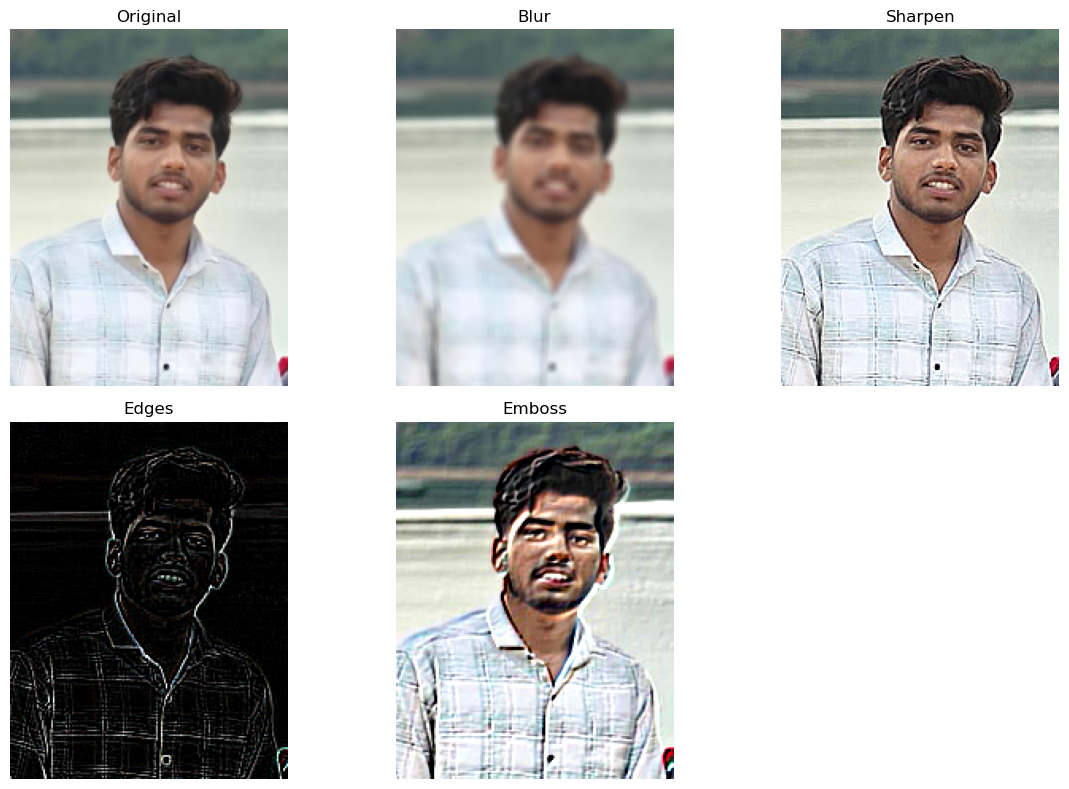

In [133]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load Image
image = cv2.imread(r"C:\Users\ashut\OneDrive\Pictures\Screenshots\Screenshot 2026-02-08 211457.png")

# Convert BGR to RGB for Matplotlib
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# --------------------------
# Blur Filter
# --------------------------
blur_kernel = np.ones((5, 5), np.float32) / 25
blurred = cv2.filter2D(image, -1, blur_kernel)

# --------------------------
# Sharpen Filter
# --------------------------
sharpen_kernel = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])

sharpened = cv2.filter2D(image, -1, sharpen_kernel)

# --------------------------
# Edge Detection Filter
# --------------------------
edge_kernel = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
])

edges = cv2.filter2D(image, -1, edge_kernel)

# --------------------------
# Emboss Filter
# --------------------------
emboss_kernel = np.array([
    [-2, -1, 0],
    [-1,  1, 1],
    [ 0,  1, 2]
])

emboss = cv2.filter2D(image, -1, emboss_kernel)

# --------------------------
# Display Results
# --------------------------
plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(image_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(cv2.cvtColor(blurred, cv2.COLOR_BGR2RGB))
plt.title("Blur")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(cv2.cvtColor(sharpened, cv2.COLOR_BGR2RGB))
plt.title("Sharpen")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(cv2.cvtColor(edges, cv2.COLOR_BGR2RGB))
plt.title("Edges")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(cv2.cvtColor(emboss, cv2.COLOR_BGR2RGB))
plt.title("Emboss")
plt.axis("off")

plt.tight_layout()
plt.show()

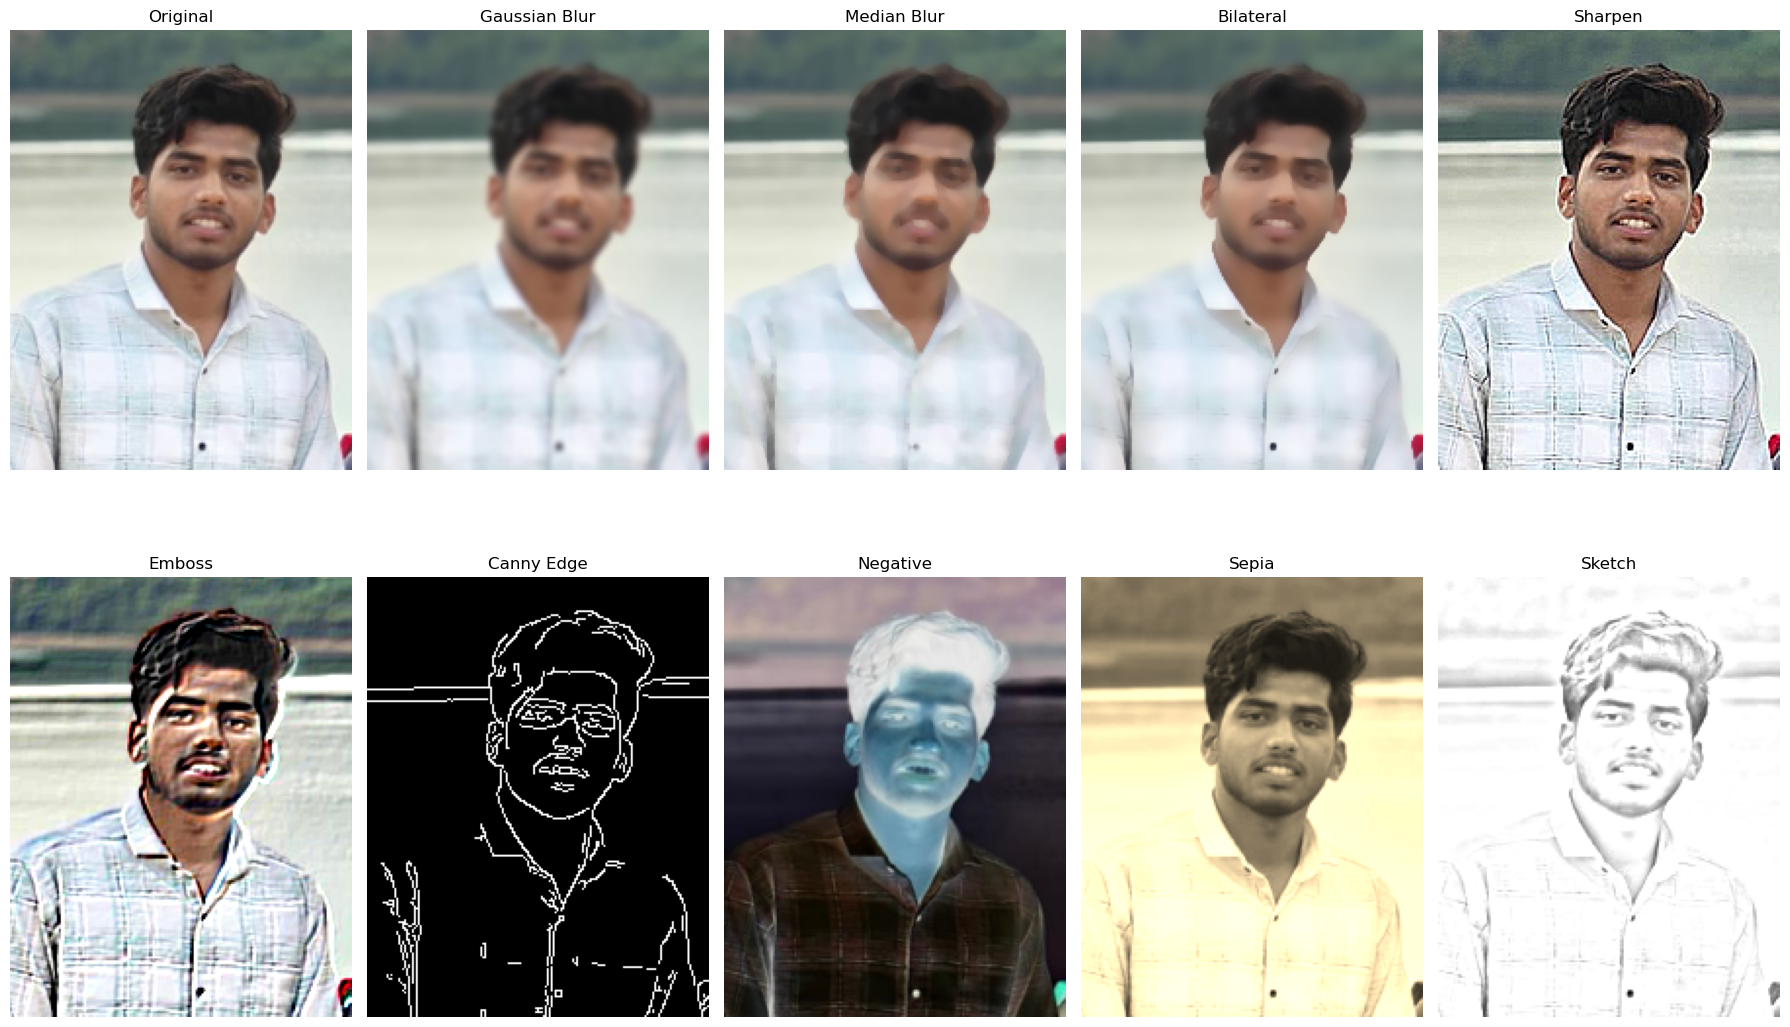

In [134]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load Image
image = cv2.imread(r"C:\Users\ashut\OneDrive\Pictures\Screenshots\Screenshot 2026-02-08 211457.png")

# Convert to RGB
rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Gaussian Blur
gaussian = cv2.GaussianBlur(image, (7, 7), 0)

# Median Blur
median = cv2.medianBlur(image, 5)

# Bilateral Filter
bilateral = cv2.bilateralFilter(image, 9, 75, 75)

# Sharpen
sharpen_kernel = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])
sharpen = cv2.filter2D(image, -1, sharpen_kernel)

# Emboss
emboss_kernel = np.array([
    [-2, -1, 0],
    [-1,  1, 1],
    [ 0,  1, 2]
])
emboss = cv2.filter2D(image, -1, emboss_kernel)

# Canny Edge Detection
canny = cv2.Canny(gray, 100, 200)

# Negative
negative = 255 - image

# Sepia
sepia_kernel = np.array([
    [0.272, 0.534, 0.131],
    [0.349, 0.686, 0.168],
    [0.393, 0.769, 0.189]
])
sepia = cv2.transform(image, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

# Sketch
inv = 255 - gray
blur = cv2.GaussianBlur(inv, (21, 21), 0)
sketch = cv2.divide(gray, 255 - blur, scale=256)

# Display Results
plt.figure(figsize=(18, 12))

images = [
    rgb,
    cv2.cvtColor(gaussian, cv2.COLOR_BGR2RGB),
    cv2.cvtColor(median, cv2.COLOR_BGR2RGB),
    cv2.cvtColor(bilateral, cv2.COLOR_BGR2RGB),
    cv2.cvtColor(sharpen, cv2.COLOR_BGR2RGB),
    cv2.cvtColor(emboss, cv2.COLOR_BGR2RGB),
    canny,
    cv2.cvtColor(negative, cv2.COLOR_BGR2RGB),
    cv2.cvtColor(sepia, cv2.COLOR_BGR2RGB),
    sketch
]

titles = [
    "Original",
    "Gaussian Blur",
    "Median Blur",
    "Bilateral",
    "Sharpen",
    "Emboss",
    "Canny Edge",
    "Negative",
    "Sepia",
    "Sketch"
]

for i in range(len(images)):
    plt.subplot(2, 5, i + 1)
    
    if len(images[i].shape) == 2:
        plt.imshow(images[i], cmap='gray')
    else:
        plt.imshow(images[i])

    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()